# RBA Risk Detection — MLP + Mamdani Fuzzy Inference System

**Môn:** Học Máy Nâng Cao — Báo cáo cuối kỳ  
**Giảng viên hướng dẫn:** TS. Phan Thị Huyền Trang  
**Nhóm 10:** Lê Phú Nhân (2591317) · Phạm Trung Kiên (2591310) · Nguyễn Minh Tuấn (2591325)  
**Lớp:** KHMT 2025B — Trường ĐH Sư phạm Kỹ thuật TP.HCM

Notebook này chuyển toàn bộ project Python thành **một file duy nhất** để chạy lần lượt trên Google Colab.

Luồng xử lý:

1. Tải dataset RBA.
2. Feature engineering theo lịch sử đăng nhập.
3. Chia Train/Validation/Test theo tỷ lệ 70/15/15.
4. Fit Mamdani FIS, `StandardScaler`, `OneHotEncoder` trên tập Train.
5. Huấn luyện MLP với `BCEWithLogitsLoss` và `pos_weight`.
6. Đánh giá, vẽ biểu đồ và lưu model.
7. Chạy thử inference với hai kịch bản rủi ro.

> Khuyến nghị: vào **Runtime → Change runtime type → T4 GPU** trước khi train.

## Pseudo-code thuật toán tổng quát

Trước khi đi vào từng cell code chi tiết, sơ đồ dưới đây thể hiện liên kết
đầu vào–đầu ra giữa các bước, từ log đăng nhập thô đến xác suất tấn công
cuối cùng.

```text
ALGORITHM  RBA-RiskScore(login_log L)
INPUT  : L = { user_id, timestamp, country, asn, device, os, browser,
               login_successful, round_trip_time, ... }
OUTPUT : attack_probability ∈ [0, 1]

──────────────────────────────────────────────────────────────
BƯỚC A · FEATURE ENGINEERING(L) → F                 (Bước 7-8)
──────────────────────────────────────────────────────────────
  F.time      ← hour_of_day, day_of_week, is_odd_hour
  F.rarity    ← country_rarity, asn_rarity                  (tần suất toàn cục)
  F.history   ← is_new_country/asn/device/os,
                time_since_last_login_h,
                user_success_rate_so_far, num_changes        (chỉ dùng shift()
                                                                về QUÁ KHỨ của
                                                                cùng user)

──────────────────────────────────────────────────────────────
BƯỚC B · FUZZY LOGIC(F) → Z                       (Bước 9, Mamdani FIS)
──────────────────────────────────────────────────────────────
  for each biến liên tục v ∈ {gap, country_rarity, asn_rarity,
                               success_rate, num_changes}:
        (low, med, high) ← FUZZIFY(v, ngưỡng percentile q20/q50/q80 trên train)

  for each luật Rᵢ ∈ RULEBASE (8 luật IF-THEN, AND=min, OR=max):
        firingᵢ ← EVALUATE(Rᵢ, low, med, high)

  agg  ← AGGREGATE(firing₁..₈, tập mờ output LOW/MED/HIGH)      # max-clip
  Z.mamdani_risk_score ← DEFUZZIFY(agg)                          # centroid
  Z.fz_*               ← toàn bộ 15 giá trị membership

──────────────────────────────────────────────────────────────
BƯỚC C · PREPROCESSING(F, Z) → X                  (Bước 10-11)
──────────────────────────────────────────────────────────────
  split(L) → train / val / test                      (70/15/15, stratified)
  scaler ← fit StandardScaler(F.numeric | train)
  ohe    ← fit OneHotEncoder(F.device_type | train)
  fis    ← fit MamdaniFuzzyRiskSystem(F | train)
  X ← concat( scaler.transform(F.numeric),
              ohe.transform(F.device_type),
              fis.transform(F) )

──────────────────────────────────────────────────────────────
BƯỚC D · MLP FORWARD(X) → ŷ                        (Bước 12)
──────────────────────────────────────────────────────────────
  h ← X
  for hidden_dim ∈ (128, 64, 32):
        h ← Dropout( BatchNorm( ReLU( Linear(h, hidden_dim) ) ) )
  logit ← Linear(h, 1)
  ŷ     ← sigmoid(logit)                          # attack_probability

──────────────────────────────────────────────────────────────
BƯỚC E · TRAINING (chỉ ở pha huấn luyện)          (Bước 13-14)
──────────────────────────────────────────────────────────────
  loss ← BCEWithLogits(logit, y_true; pos_weight = n_neg/n_pos)
  ∇θ   ← Backward(loss)
  θ    ← θ − Adam_update(∇θ, lr=1e-3, weight_decay=1e-5)
  lặp lại theo mini-batch (4096 mẫu) × tối đa 30 epoch
  dừng sớm nếu val_AUPRC không cải thiện sau 5 epoch

RETURN ŷ = attack_probability
```


## Bước 1 — Cài đặt thư viện

In [ ]:
# PyTorch đã được cài sẵn trên Google Colab, không cài lại để tránh mất CUDA.
!pip -q install "numpy>=1.24" "pandas>=2.0" "scikit-learn>=1.3" "matplotlib>=3.7"

## Bước 2 — Import thư viện và thiết lập môi trường

In [ ]:
import os
import json
import time
import pickle
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

from IPython.display import display, Image

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Python/PyTorch environment ready")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python/PyTorch environment ready
PyTorch: 2.11.0+cpu
CUDA available: False


## Bước 3 — Cấu hình

In [ ]:
# ===================== ĐƯỜNG DẪN =====================
OUTPUT_DIR = Path("/content/rba_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "mlp_mamdani_model.pt"
PIPELINE_PATH = OUTPUT_DIR / "preprocessing_pipeline.pkl"
METRICS_PATH = OUTPUT_DIR / "metrics.json"

# Dataset được đặt trong thư mục mặc định của Google Colab:
# /content/sample_data/
DATA_DIR = Path("/content/sample_data")

# Tên file CSV cần đọc.
# Đổi giá trị này nếu file bạn upload có tên khác.
DATA_FILE_NAME = "rba_sample_500k.csv"
DATA_PATH = DATA_DIR / DATA_FILE_NAME

# None = dùng toàn bộ dữ liệu.
# Khi muốn chạy thử nhanh, có thể đặt 50000 hoặc 100000.
MAX_ROWS = None

# ===================== CỘT TARGET =====================
TARGET_COLUMN = "Is Attack IP"

# ===================== CHIA DỮ LIỆU =====================
RANDOM_STATE = 42
TEST_SIZE = 0.30       # 30% cho Validation + Test
VAL_TEST_SPLIT = 0.50  # 15% Validation + 15% Test

# ===================== MLP =====================
EPOCHS = 30
BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
HIDDEN_DIMS = (128, 64, 32)
DROPOUT = 0.30
EARLY_STOPPING_PATIENCE = 5

# ===================== MAMDANI FIS =====================
FUZZY_OUTPUT_GRID_POINTS = 51

# Cố định seed để kết quả có thể tái lập gần nhất có thể.
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

print("DATA_PATH :", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("EPOCHS:", EPOCHS, "| BATCH_SIZE:", BATCH_SIZE)


DATA_PATH : /content/sample_data/rba_sample_500k.csv
OUTPUT_DIR: /content/rba_outputs
EPOCHS: 30 | BATCH_SIZE: 4096


## Bước 4 — Chuẩn bị dữ liệu trong `sample_data`

Trước khi chạy bước này, hãy upload file CSV vào thư mục:

`/content/sample_data/`

Tên file mặc định trong notebook là:

`rba_sample_500k.csv`

Nếu file có tên khác, sửa biến `DATA_FILE_NAME` ở cell cấu hình phía trên.

Dataset cần có tối thiểu các cột:

`Login Timestamp`, `User ID`, `Round-Trip Time [ms]`, `Country`, `City`, `ASN`, `Device Type`, `Browser Name and Version`, `OS Name and Version`, `Login Successful`, `Is Attack IP`.


In [ ]:
# Kiểm tra thư mục và file dữ liệu trong /content/sample_data
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Không tìm thấy thư mục dữ liệu: {DATA_DIR}")

csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Các file CSV hiện có trong sample_data:")
if csv_files:
    for file_path in csv_files:
        size_mb = file_path.stat().st_size / 1024**2
        print(f"- {file_path.name} ({size_mb:.2f} MB)")
else:
    print("- Chưa có file CSV nào")

if not DATA_PATH.exists():
    available_names = [p.name for p in csv_files]
    raise FileNotFoundError(
        f"Không tìm thấy file: {DATA_PATH}\n"
        f"Các file CSV hiện có: {available_names}\n"
        "Hãy upload file vào /content/sample_data hoặc sửa DATA_FILE_NAME."
    )

print("\nDataset được sử dụng:", DATA_PATH)
print("Dung lượng:", round(DATA_PATH.stat().st_size / 1024**2, 2), "MB")


Các file CSV hiện có trong sample_data:
- california_housing_test.csv (0.29 MB)
- california_housing_train.csv (1.63 MB)
- mnist_test.csv (17.44 MB)
- mnist_train_small.csv (34.83 MB)
- rba_sample_500k.csv (60.00 MB)

Dataset được sử dụng: /content/sample_data/rba_sample_500k.csv
Dung lượng: 60.0 MB


## Bước 5 — Đọc và kiểm tra dữ liệu thô

In [ ]:
t0 = time.time()

df_raw = pd.read_csv(DATA_PATH, nrows=MAX_ROWS)
df_raw["Login Timestamp"] = pd.to_datetime(df_raw["Login Timestamp"])
df_raw = df_raw.sort_values(["User ID", "Login Timestamp"]).reset_index(drop=True)

print(f"Đã đọc {len(df_raw):,} dòng trong {time.time() - t0:.2f} giây")
print("Số cột:", df_raw.shape[1])
if MAX_ROWS is not None:
    print(f"(Đang chạy thử với MAX_ROWS = {MAX_ROWS:,} dòng đầu tiên)")
display(df_raw.head())


Đã đọc 246,646 dòng trong 4.77 giây
Số cột: 16


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,20884278,2020-11-16 12:39:57.672,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.77,Mac OS X 10.14.6,desktop,False,False,False
1,20884602,2020-11-16 12:43:41.722,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,False,False
2,20884895,2020-11-16 12:46:46.624,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.77,Mac OS X 10.14.6,desktop,True,False,False
3,20885943,2020-11-16 12:59:04.508,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,False,False
4,20886208,2020-11-16 13:01:54.652,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,False,False


In [ ]:
# ============================================================
# BƯỚC 5: KIỂM TRA VÀ LÀM SẠCH CỘT NHÃN
# ============================================================

import pandas as pd

# Kiểm tra cột target có tồn tại
if TARGET_COLUMN not in df_raw.columns:
    raise KeyError(
        f"Không tìm thấy cột target '{TARGET_COLUMN}'.\n"
        f"Các cột hiện có:\n{df_raw.columns.tolist()}"
    )

print("KÍCH THƯỚC DỮ LIỆU BAN ĐẦU")
print(f"Số dòng: {len(df_raw):,}")
print(f"Số cột : {df_raw.shape[1]}")

# Lưu target gốc để kiểm tra
target_raw = df_raw[TARGET_COLUMN].copy()

# Series kết quả, cho phép chứa giá trị thiếu tạm thời
target_clean = pd.Series(
    pd.NA,
    index=df_raw.index,
    dtype="Int64"
)

# ------------------------------------------------------------
# 1. Chuyển các giá trị dạng số: 0, 1, 0.0, 1.0
# ------------------------------------------------------------
target_numeric = pd.to_numeric(target_raw, errors="coerce")

target_clean.loc[target_numeric.eq(0)] = 0
target_clean.loc[target_numeric.eq(1)] = 1

# ------------------------------------------------------------
# 2. Chuyển các giá trị dạng chuỗi
# ------------------------------------------------------------
target_text = (
    target_raw
    .astype("string")
    .str.strip()
    .str.lower()
)

label_mapping = {
    # Nhãn bình thường
    "0": 0,
    "0.0": 0,
    "false": 0,
    "no": 0,
    "n": 0,
    "normal": 0,
    "benign": 0,
    "not attack": 0,
    "non-attack": 0,

    # Nhãn tấn công
    "1": 1,
    "1.0": 1,
    "true": 1,
    "yes": 1,
    "y": 1,
    "attack": 1,
    "malicious": 1
}

target_from_text = target_text.map(label_mapping)

# Chỉ bổ sung cho các giá trị chưa chuyển được ở bước số
target_clean = target_clean.fillna(target_from_text)

# ------------------------------------------------------------
# 3. Thống kê dữ liệu target bị thiếu hoặc không hợp lệ
# ------------------------------------------------------------
missing_original = target_raw.isna().sum()
invalid_mask = target_clean.isna()
invalid_count = invalid_mask.sum()

print("\nKIỂM TRA TARGET")
print(f"Target bị thiếu ban đầu       : {missing_original:,}")
print(f"Target thiếu/không hợp lệ     : {invalid_count:,}")

# Hiển thị một số giá trị không chuyển đổi được
unknown_values = (
    target_raw.loc[invalid_mask & target_raw.notna()]
    .astype(str)
    .value_counts()
    .head(20)
)

if not unknown_values.empty:
    print("\nCác giá trị target không hợp lệ:")
    display(
        unknown_values
        .rename_axis("Giá trị")
        .reset_index(name="Số lượng")
    )

# ------------------------------------------------------------
# 4. Loại các dòng không có target hợp lệ
# ------------------------------------------------------------
valid_mask = target_clean.notna()

df_raw = df_raw.loc[valid_mask].copy()

df_raw[TARGET_COLUMN] = (
    target_clean.loc[valid_mask]
    .astype("int8")
)

# Reset index sau khi loại dòng
df_raw.reset_index(drop=True, inplace=True)

# ------------------------------------------------------------
# 5. Kiểm tra kết quả
# ------------------------------------------------------------
if df_raw.empty:
    raise ValueError(
        "Không còn dữ liệu sau khi làm sạch target. "
        "Hãy kiểm tra lại giá trị trong cột target."
    )

class_counts = df_raw[TARGET_COLUMN].value_counts().sort_index()

if len(class_counts) < 2:
    raise ValueError(
        f"Cột target chỉ còn một lớp: {class_counts.to_dict()}. "
        "Mô hình phân loại cần cả nhãn 0 và nhãn 1."
    )

print("\nKẾT QUẢ SAU KHI LÀM SẠCH")
print(f"Số dòng còn lại        : {len(df_raw):,}")
print(f"Số dòng đã loại        : {invalid_count:,}")
print(f"Tỷ lệ Is Attack IP = 1 : {df_raw[TARGET_COLUMN].mean():.4%}")

print("\nPHÂN BỐ NHÃN")
display(
    pd.DataFrame({
        "Số lượng": class_counts,
        "Tỷ lệ": class_counts / len(df_raw)
    }).rename_axis(TARGET_COLUMN)
)

display(df_raw.head())

KÍCH THƯỚC DỮ LIỆU BAN ĐẦU
Số dòng: 246,646
Số cột : 16

KIỂM TRA TARGET
Target bị thiếu ban đầu       : 1
Target thiếu/không hợp lệ     : 1

KẾT QUẢ SAU KHI LÀM SẠCH
Số dòng còn lại        : 246,645
Số dòng đã loại        : 1
Tỷ lệ Is Attack IP = 1 : 3.1069%

PHÂN BỐ NHÃN


,Số lượng,Tỷ lệ
Is Attack IP,,
0,238982,0.968931
1,7663,0.031069


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,20884278,2020-11-16 12:39:57.672,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.77,Mac OS X 10.14.6,desktop,False,0,False
1,20884602,2020-11-16 12:43:41.722,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,0,False
2,20884895,2020-11-16 12:46:46.624,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 72.0.3626.77,Mac OS X 10.14.6,desktop,True,0,False
3,20885943,2020-11-16 12:59:04.508,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,0,False
4,20886208,2020-11-16 13:01:54.652,-9222331807151947514,NaN,10.0.160.41,NO,-,-,8478.0,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_6...,Chrome 69.0.3497.17.21,Mac OS X 10.14.6,desktop,True,0,False


## Bước 6 — Khai báo các đặc trưng

In [ ]:
FEATURE_COLUMNS_NUMERIC = [
    "hour_of_day", "day_of_week", "is_weekend", "is_odd_hour",
    "rtt_filled", "rtt_missing",
    "country_rarity", "asn_rarity",
    "time_since_last_login_h", "is_first_login",
    "is_new_country", "is_new_city", "is_new_asn",
    "is_new_device", "is_new_browser", "is_new_os",
    "user_success_rate_so_far", "user_login_count_so_far",
    "num_changes",
]

FEATURE_COLUMNS_CATEGORICAL = ["Device Type"]

print("Numeric features:", len(FEATURE_COLUMNS_NUMERIC))
print("Categorical features:", FEATURE_COLUMNS_CATEGORICAL)

Numeric features: 19
Categorical features: ['Device Type']


## Bước 7 — Feature engineering theo lịch sử đăng nhập

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # 1. Đặc trưng thời gian
    df["hour_of_day"] = df["Login Timestamp"].dt.hour
    df["day_of_week"] = df["Login Timestamp"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_odd_hour"] = ((df["hour_of_day"] < 6) | (df["hour_of_day"] > 22)).astype(int)

    # 2. Round-Trip Time
    df["rtt_missing"] = df["Round-Trip Time [ms]"].isna().astype(int)
    rtt_median = df["Round-Trip Time [ms]"].median()
    df["rtt_filled"] = df["Round-Trip Time [ms]"].fillna(rtt_median)

    # 3. Độ hiếm Country/ASN trong dataset
    country_freq = df["Country"].value_counts(normalize=True)
    asn_freq = df["ASN"].value_counts(normalize=True)
    df["country_rarity"] = 1 - df["Country"].map(country_freq).fillna(0)
    df["asn_rarity"] = 1 - df["ASN"].map(asn_freq).fillna(0)

    # 4. Lịch sử theo từng User ID
    g = df.groupby("User ID", sort=False)
    df["prev_timestamp"] = g["Login Timestamp"].shift(1)
    df["time_since_last_login_h"] = (
        (df["Login Timestamp"] - df["prev_timestamp"]).dt.total_seconds() / 3600.0
    )
    df["is_first_login"] = df["prev_timestamp"].isna().astype(int)
    df["time_since_last_login_h"] = df["time_since_last_login_h"].fillna(24 * 365)

    for col, new_col in [
        ("Country", "is_new_country"),
        ("City", "is_new_city"),
        ("ASN", "is_new_asn"),
        ("Device Type", "is_new_device"),
        ("Browser Name and Version", "is_new_browser"),
        ("OS Name and Version", "is_new_os"),
    ]:
        prev = g[col].shift(1)
        df[new_col] = (df[col] != prev).astype(int)
        df.loc[df["is_first_login"] == 1, new_col] = 1

    success_int = df["Login Successful"].astype(int)
    cum_success = success_int.groupby(df["User ID"]).cumsum() - success_int
    cum_count = df.groupby("User ID").cumcount()
    df["user_success_rate_so_far"] = (
        cum_success / cum_count.replace(0, np.nan)
    ).fillna(1.0)
    df["user_login_count_so_far"] = cum_count

    change_cols = [
        "is_new_country", "is_new_city", "is_new_asn",
        "is_new_device", "is_new_browser", "is_new_os",
    ]
    df["num_changes"] = df[change_cols].sum(axis=1)

    return df

## Bước 8 — Chạy feature engineering

In [ ]:
t0 = time.time()
df = engineer_features(df_raw)

print(f"Hoàn tất feature engineering trong {time.time() - t0:.2f} giây")
print("Shape sau feature engineering:", df.shape)
display(df[FEATURE_COLUMNS_NUMERIC + FEATURE_COLUMNS_CATEGORICAL + [TARGET_COLUMN]].head())

Hoàn tất feature engineering trong 0.49 giây
Shape sau feature engineering: (246645, 36)


,hour_of_day,day_of_week,is_weekend,is_odd_hour,rtt_filled,rtt_missing,country_rarity,asn_rarity,time_since_last_login_h,is_first_login,is_new_country,is_new_city,is_new_asn,is_new_device,is_new_browser,is_new_os,user_success_rate_so_far,user_login_count_so_far,num_changes,Device Type,Is Attack IP
0,12,0,0,0,535.0,1,0.179996,0.992382,8760.000000,1,1,1,1,1,1,1,1.000000,0,6,desktop,0
1,12,0,0,0,535.0,1,0.179996,0.992382,0.062236,0,0,0,0,0,1,0,0.000000,1,1,desktop,0
2,12,0,0,0,535.0,1,0.179996,0.992382,0.051362,0,0,0,0,0,1,0,0.500000,2,1,desktop,0
3,12,0,0,0,535.0,1,0.179996,0.992382,0.204968,0,0,0,0,0,1,0,0.666667,3,1,desktop,0
4,13,0,0,0,535.0,1,0.179996,0.992382,0.047262,0,0,0,0,0,0,0,0.750000,4,0,desktop,0


## Bước 9 — Xây dựng Mamdani Fuzzy Inference System

Mỗi biến liên tục được lấy ba ngưỡng percentile từ **tập Train**:

- `q20`: percentile 20%.
- `q50`: trung vị, percentile 50%.
- `q80`: percentile 80%.

Bốn bước Mamdani:

1. Fuzzification thành Low/Medium/High.
2. Đánh giá luật với `AND = min`, `OR = max`.
3. Cắt và tổng hợp tập mờ đầu ra bằng `max`.
4. Defuzzification bằng phương pháp centroid.

In [ ]:
def triangular(x, a, b, c):
    """Hàm thành viên tam giác, trả về giá trị trong [0, 1]."""
    x = np.asarray(x, dtype=np.float64)
    a, b, c = float(a), float(b), float(c)
    y = np.zeros_like(x)

    if a == b == c:
        y[np.isclose(x, b)] = 1.0
        return np.clip(y, 0, 1).astype(np.float32)

    left = (x >= a) & (x <= b) & (b > a)
    y[left] = (x[left] - a) / (b - a)

    right = (x > b) & (x <= c) & (c > b)
    y[right] = (c - x[right]) / (c - b)

    y[np.isclose(x, b)] = 1.0
    return np.clip(y, 0, 1).astype(np.float32)


def low_med_high(x, p20, p50, p80):
    x = np.asarray(x, dtype=np.float64)
    xmin, xmax = float(np.min(x)), float(np.max(x))

    low = triangular(x, xmin, xmin, p50)
    med = triangular(x, p20, p50, p80)
    high = triangular(x, p50, xmax, xmax)
    return low, med, high


class MamdaniFuzzyRiskSystem:
    CONTINUOUS_VARS = [
        "time_since_last_login_h",
        "country_rarity",
        "asn_rarity",
        "user_success_rate_so_far",
        "num_changes",
    ]

    N_GRID = FUZZY_OUTPUT_GRID_POINTS
    Y_GRID = np.linspace(0, 1, N_GRID, dtype=np.float32)
    OUT_LOW = triangular(Y_GRID, 0.0, 0.0, 0.5)
    OUT_MED = triangular(Y_GRID, 0.2, 0.5, 0.8)
    OUT_HIGH = triangular(Y_GRID, 0.5, 1.0, 1.0)

    def fit(self, data: pd.DataFrame):
        self.thresholds_ = {
            col: np.percentile(data[col].values, [20, 50, 80])
            for col in self.CONTINUOUS_VARS
        }
        return self

    def _fuzzify(self, data):
        return {
            col: low_med_high(data[col].values, *self.thresholds_[col])
            for col in self.CONTINUOUS_VARS
        }

    def _rule_base(self, mem, data):
        gap_low, gap_med, gap_high = mem["time_since_last_login_h"]
        crare_low, crare_med, crare_high = mem["country_rarity"]
        arare_low, arare_med, arare_high = mem["asn_rarity"]
        succ_low, succ_med, succ_high = mem["user_success_rate_so_far"]
        chg_low, chg_med, chg_high = mem["num_changes"]

        is_new_country = data["is_new_country"].values.astype(np.float32)
        is_new_asn = data["is_new_asn"].values.astype(np.float32)
        not_new_country = 1.0 - is_new_country
        not_new_asn = 1.0 - is_new_asn

        return [
            (np.minimum.reduce([is_new_country, is_new_asn, gap_high]), "high"),
            (succ_low, "high"),
            (chg_high, "high"),
            (arare_high, "high"),
            (np.minimum.reduce([not_new_country, not_new_asn, chg_low, succ_high]), "low"),
            (np.minimum(gap_low, crare_low), "low"),
            (np.maximum(chg_med, gap_med), "med"),
            (np.minimum(succ_med, np.maximum(not_new_country, not_new_asn)), "med"),
        ]

    def transform(self, data: pd.DataFrame) -> pd.DataFrame:
        mem = self._fuzzify(data)
        rules = self._rule_base(mem, data)
        n = len(data)

        aggregated = np.zeros((n, self.N_GRID), dtype=np.float32)
        output_shapes = {
            "low": self.OUT_LOW,
            "med": self.OUT_MED,
            "high": self.OUT_HIGH,
        }

        for firing_strength, label in rules:
            clipped = np.minimum(
                output_shapes[label][None, :],
                firing_strength[:, None].astype(np.float32),
            )
            np.maximum(aggregated, clipped, out=aggregated)

        numerator = aggregated @ self.Y_GRID
        denominator = aggregated.sum(axis=1)
        centroid = np.divide(
            numerator,
            denominator,
            out=np.full(n, 0.5, dtype=np.float32),
            where=denominator > 1e-6,
        )

        output = {}
        for col in self.CONTINUOUS_VARS:
            low, med, high = mem[col]
            output[f"fz_{col}_low"] = low
            output[f"fz_{col}_med"] = med
            output[f"fz_{col}_high"] = high

        output["mamdani_risk_score"] = centroid
        return pd.DataFrame(output, index=data.index)


FUZZY_FEATURE_COLUMNS = [
    f"fz_{col}_{level}"
    for col in MamdaniFuzzyRiskSystem.CONTINUOUS_VARS
    for level in ("low", "med", "high")
] + ["mamdani_risk_score"]

print("Số fuzzy features:", len(FUZZY_FEATURE_COLUMNS))

Số fuzzy features: 16


## Bước 10 — Chia Train/Validation/Test và fit pipeline tiền xử lý

In [ ]:
def prepare_splits(data: pd.DataFrame):
    y = data[TARGET_COLUMN].astype(int).values
    indices = np.arange(len(data))

    idx_train, idx_temp, y_train, y_temp = train_test_split(
        indices,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    idx_val, idx_test, y_val, y_test = train_test_split(
        idx_temp,
        y_temp,
        test_size=VAL_TEST_SPLIT,
        random_state=RANDOM_STATE,
        stratify=y_temp,
    )

    df_train = data.iloc[idx_train].copy()
    df_val = data.iloc[idx_val].copy()
    df_test = data.iloc[idx_test].copy()

    # Fit Mamdani FIS chỉ trên Train
    fis = MamdaniFuzzyRiskSystem().fit(df_train)
    fz_train = fis.transform(df_train)
    fz_val = fis.transform(df_val)
    fz_test = fis.transform(df_test)

    # Fit OneHotEncoder chỉ trên Train
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    ohe.fit(df_train[FEATURE_COLUMNS_CATEGORICAL])
    cat_cols = list(ohe.get_feature_names_out(FEATURE_COLUMNS_CATEGORICAL))

    def make_cat(frame):
        return pd.DataFrame(
            ohe.transform(frame[FEATURE_COLUMNS_CATEGORICAL]),
            columns=cat_cols,
            index=frame.index,
        )

    cat_train = make_cat(df_train)
    cat_val = make_cat(df_val)
    cat_test = make_cat(df_test)

    # Fit StandardScaler chỉ trên Train
    scaler = StandardScaler()
    num_train = pd.DataFrame(
        scaler.fit_transform(df_train[FEATURE_COLUMNS_NUMERIC]),
        columns=FEATURE_COLUMNS_NUMERIC,
        index=df_train.index,
    )
    num_val = pd.DataFrame(
        scaler.transform(df_val[FEATURE_COLUMNS_NUMERIC]),
        columns=FEATURE_COLUMNS_NUMERIC,
        index=df_val.index,
    )
    num_test = pd.DataFrame(
        scaler.transform(df_test[FEATURE_COLUMNS_NUMERIC]),
        columns=FEATURE_COLUMNS_NUMERIC,
        index=df_test.index,
    )

    X_train = pd.concat([num_train, cat_train, fz_train], axis=1)
    X_val = pd.concat([num_val, cat_val, fz_val], axis=1)
    X_test = pd.concat([num_test, cat_test, fz_test], axis=1)

    pipeline = {
        "scaler": scaler,
        "ohe": ohe,
        "fis_thresholds": fis.thresholds_,
        "cat_cols": cat_cols,
        "input_columns": list(X_train.columns),
        "input_dim": X_train.shape[1],
        "hidden_dims": HIDDEN_DIMS,
        "dropout": DROPOUT,
        "target_column": TARGET_COLUMN,
    }

    return {
        "X": (X_train, X_val, X_test),
        "y": (y_train, y_val, y_test),
        "df_splits": (df_train, df_val, df_test),
        "pipeline": pipeline,
    }

## Bước 11 — Thực hiện chia dữ liệu và xem các ngưỡng q20/q50/q80

In [ ]:
t0 = time.time()
data = prepare_splits(df)

X_train, X_val, X_test = data["X"]
y_train, y_val, y_test = data["y"]
df_train, df_val, df_test = data["df_splits"]
pipeline = data["pipeline"]

print(f"Hoàn tất preprocessing trong {time.time() - t0:.2f} giây")
print(f"Train      : {len(y_train):,} dòng | positive rate = {y_train.mean():.4%}")
print(f"Validation : {len(y_val):,} dòng | positive rate = {y_val.mean():.4%}")
print(f"Test       : {len(y_test):,} dòng | positive rate = {y_test.mean():.4%}")
print("Input dimension:", pipeline["input_dim"])

threshold_table = pd.DataFrame(
    pipeline["fis_thresholds"],
    index=["q20", "q50", "q80"],
).T
threshold_table.index.name = "Fuzzy input"
display(threshold_table)

display(X_train.head())

Hoàn tất preprocessing trong 1.24 giây
Train      : 172,651 dòng | positive rate = 3.1068%
Validation : 36,997 dòng | positive rate = 3.1084%
Test       : 36,997 dòng | positive rate = 3.1057%
Input dimension: 39


,q20,q50,q80
Fuzzy input,,,
time_since_last_login_h,0.190427,44.986691,362.328615
country_rarity,0.179996,0.179996,0.179996
asn_rarity,0.477435,0.477435,0.994543
user_success_rate_so_far,0.750000,0.947368,1.000000
num_changes,0.000000,1.000000,3.000000


,hour_of_day,day_of_week,is_weekend,is_odd_hour,rtt_filled,rtt_missing,country_rarity,asn_rarity,time_since_last_login_h,is_first_login,is_new_country,is_new_city,is_new_asn,is_new_device,is_new_browser,is_new_os,user_success_rate_so_far,user_login_count_so_far,num_changes,Device Type_desktop,Device Type_mobile,Device Type_tablet,Device Type_unknown,fz_time_since_last_login_h_low,fz_time_since_last_login_h_med,fz_time_since_last_login_h_high,fz_country_rarity_low,fz_country_rarity_med,fz_country_rarity_high,fz_asn_rarity_low,fz_asn_rarity_med,fz_asn_rarity_high,fz_user_success_rate_so_far_low,fz_user_success_rate_so_far_med,fz_user_success_rate_so_far_high,fz_num_changes_low,fz_num_changes_med,fz_num_changes_high,mamdani_risk_score
180230,-2.403234,-1.415607,-0.5418,3.192410,-0.032066,0.250576,-0.467213,-0.954209,-0.216960,-0.173175,-0.206162,1.453738,2.195902,1.949631,1.309344,1.627731,0.653152,-0.895893,2.078200,0.0,1.0,0.0,0.0,0.000000,0.716685,0.010316,1.0,1.0,0.000000,1.0,1.0,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.8,0.657433
29378,0.229699,-0.903734,-0.5418,-0.313243,-0.032066,0.250576,-0.467213,-0.954209,-0.303669,-0.173175,-0.206162,-0.687882,-0.455394,1.949631,1.309344,1.627731,0.411599,1.135154,0.928615,0.0,0.0,1.0,0.0,0.890648,0.105566,0.000000,1.0,1.0,0.000000,1.0,1.0,0.000000,0.004193,0.979874,0.0,0.0,0.0,0.4,0.439071
72827,-0.146434,0.120011,-0.5418,-0.313243,-0.032066,0.250576,2.201727,1.132000,-0.306945,-0.173175,-0.206162,-0.687882,-0.455394,-0.512917,-0.763741,-0.614352,-0.831178,-0.036604,-0.795763,0.0,1.0,0.0,0.0,0.999802,0.000000,0.000000,0.0,0.0,0.996213,0.0,0.0,0.997494,0.311594,0.000000,0.0,1.0,0.0,0.0,0.839969
236419,0.417766,-0.903734,-0.5418,-0.313243,-0.032066,0.250576,-0.467213,-0.954209,0.356114,-0.173175,-0.206162,1.453738,2.195902,-0.512917,1.309344,-0.614352,-0.058089,-0.231897,0.928615,1.0,0.0,0.0,0.0,0.000000,0.000000,0.108885,1.0,1.0,0.000000,1.0,1.0,0.000000,0.120370,0.422222,0.0,0.0,0.0,0.4,0.630925
58215,0.981966,0.120011,-0.5418,-0.313243,-0.032066,0.250576,-0.467213,1.133119,-0.192477,-0.173175,-0.206162,-0.687882,-0.455394,1.949631,1.309344,1.627731,-0.020656,-0.192838,0.928615,0.0,1.0,0.0,0.0,0.000000,0.601038,0.014528,1.0,1.0,0.000000,0.0,0.0,0.998029,0.111111,0.466667,0.0,0.0,0.0,0.4,0.673803


## Bước 12 — Khai báo kiến trúc MLP

In [ ]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=HIDDEN_DIMS, dropout=DROPOUT):
        super().__init__()

        layers = []
        previous_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(previous_dim, hidden_dim),
                nn.ReLU(),
                nn.BatchNorm1d(hidden_dim),
                nn.Dropout(dropout),
            ])
            previous_dim = hidden_dim

        layers.append(nn.Linear(previous_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def to_tensor(data):
    array = data.values if hasattr(data, "values") else data
    return torch.tensor(array, dtype=torch.float32)


model_preview = MLPClassifier(pipeline["input_dim"])
print(model_preview)
print("Số tham số trainable:", sum(p.numel() for p in model_preview.parameters() if p.requires_grad))

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Số tham số trainable: 15937


## Bước 13 — Hàm huấn luyện MLP

In [ ]:
def train_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    input_dim,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    seed=RANDOM_STATE,
    verbose=True,
):
    torch.manual_seed(seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = MLPClassifier(input_dim).to(device)

    Xtr_t = to_tensor(X_train)
    ytr_t = to_tensor(y_train)
    Xv_t = to_tensor(X_val).to(device)

    loader = DataLoader(
        TensorDataset(Xtr_t, ytr_t),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=torch.cuda.is_available(),
    )

    n_pos = ytr_t.sum().item()
    n_neg = len(ytr_t) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
    )

    best_auprc = -1.0
    best_state = None
    bad_epochs = 0

    history = {
        "epoch": [],
        "train_loss": [],
        "val_auprc": [],
        "val_auroc": [],
        "learning_rate": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(xb)

        total_loss /= len(Xtr_t)

        model.eval()
        with torch.no_grad():
            val_probs = torch.sigmoid(model(Xv_t)).cpu().numpy()

        val_auprc = average_precision_score(y_val, val_probs)
        val_auroc = roc_auc_score(y_val, val_probs)
        scheduler.step(val_auprc)
        current_lr = optimizer.param_groups[0]["lr"]

        history["epoch"].append(epoch)
        history["train_loss"].append(total_loss)
        history["val_auprc"].append(val_auprc)
        history["val_auroc"].append(val_auroc)
        history["learning_rate"].append(current_lr)

        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"loss={total_loss:.4f} | "
                f"val_AUPRC={val_auprc:.4f} | "
                f"val_AUROC={val_auroc:.4f} | "
                f"lr={current_lr:.2e}"
            )

        if val_auprc > best_auprc:
            best_auprc = val_auprc
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= EARLY_STOPPING_PATIENCE:
                print(
                    f"Early stopping tại epoch {epoch}; "
                    f"best validation AUPRC = {best_auprc:.4f}"
                )
                break

    if best_state is None:
        raise RuntimeError("Không lưu được trạng thái model tốt nhất.")

    model.load_state_dict(best_state)
    model.to(device)
    return model, device, history

## Bước 14 — Huấn luyện mô hình

In [ ]:
t0 = time.time()

model, device, history = train_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    input_dim=pipeline["input_dim"],
)

print(f"Train xong trong {(time.time() - t0) / 60:.2f} phút")
print("Device:", device)

Epoch 01/30 | loss=1.1617 | val_AUPRC=0.1239 | val_AUROC=0.8282 | lr=1.00e-03
Epoch 02/30 | loss=1.0904 | val_AUPRC=0.1275 | val_AUROC=0.8349 | lr=1.00e-03
Epoch 03/30 | loss=1.0572 | val_AUPRC=0.1303 | val_AUROC=0.8361 | lr=1.00e-03
Epoch 04/30 | loss=1.0403 | val_AUPRC=0.1289 | val_AUROC=0.8386 | lr=1.00e-03
Epoch 05/30 | loss=1.0278 | val_AUPRC=0.1346 | val_AUROC=0.8406 | lr=1.00e-03
Epoch 06/30 | loss=1.0147 | val_AUPRC=0.1334 | val_AUROC=0.8424 | lr=1.00e-03
Epoch 07/30 | loss=1.0049 | val_AUPRC=0.1369 | val_AUROC=0.8430 | lr=1.00e-03
Epoch 08/30 | loss=0.9936 | val_AUPRC=0.1423 | val_AUROC=0.8450 | lr=1.00e-03
Epoch 09/30 | loss=0.9872 | val_AUPRC=0.1403 | val_AUROC=0.8474 | lr=1.00e-03
Epoch 10/30 | loss=0.9781 | val_AUPRC=0.1402 | val_AUROC=0.8477 | lr=1.00e-03
Epoch 11/30 | loss=0.9789 | val_AUPRC=0.1483 | val_AUROC=0.8501 | lr=1.00e-03
Epoch 12/30 | loss=0.9713 | val_AUPRC=0.1452 | val_AUROC=0.8518 | lr=1.00e-03
Epoch 13/30 | loss=0.9648 | val_AUPRC=0.1519 | val_AUROC=0.8532 

## Bước 15 — Hàm đánh giá mô hình

In [ ]:
def evaluate(model, X, y, device, threshold=0.5):
    model.eval()

    with torch.no_grad():
        probs = torch.sigmoid(model(to_tensor(X).to(device))).cpu().numpy()

    preds = (probs >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y,
        preds,
        average="binary",
        zero_division=0,
    )

    return {
        "AUROC": roc_auc_score(y, probs),
        "AUPRC": average_precision_score(y, probs),
        "Accuracy": accuracy_score(y, preds),
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "threshold": threshold,
        "probs": probs,
        "preds": preds,
        "y_true": np.asarray(y),
        "confusion_matrix": confusion_matrix(y, preds),
    }

## Bước 16 — Đánh giá trên tập Test

In [ ]:
METRICS = ["AUROC", "AUPRC", "Accuracy", "Precision", "Recall", "F1"]

results = evaluate(model, X_test, y_test, device, threshold=0.5)
metrics_df = pd.DataFrame(
    {"Metric": METRICS, "Score": [results[m] for m in METRICS]}
)

display(metrics_df.style.format({"Score": "{:.4f}"}))
print("Confusion matrix:\n", results["confusion_matrix"])

,Metric,Score
0,AUROC,0.8664
1,AUPRC,0.2226
2,Accuracy,0.7540
3,Precision,0.0986
4,Recall,0.8494
5,F1,0.1766


Confusion matrix:
 [[26921  8927]
 [  173   976]]


## Bước 17 — Vẽ biểu đồ đánh giá

In [ ]:
def save_and_show(fig, filename):
    path = OUTPUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print("Đã lưu:", path)


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(history["epoch"], history["train_loss"], marker="o")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Train Loss (BCE)")
    axes[0].set_title("Training Loss theo Epoch")
    axes[0].grid(alpha=0.25)

    axes[1].plot(history["epoch"], history["val_auprc"], marker="o", label="Validation AUPRC")
    axes[1].plot(history["epoch"], history["val_auroc"], marker="s", label="Validation AUROC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Validation AUPRC và AUROC")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    save_and_show(fig, "training_curves.png")


def plot_metrics_bar(results):
    values = [results[m] for m in METRICS]
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.bar(METRICS, values)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Điểm số")
    ax.set_title("Chỉ số đánh giá MLP + Mamdani FIS trên Test set")

    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
        )

    save_and_show(fig, "metrics_bar_chart.png")


def plot_confusion_matrix_chart(results):
    cm = results["confusion_matrix"]
    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(cm, cmap="Blues")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Bình thường", "Tấn công"])
    ax.set_yticklabels(["Bình thường", "Tấn công"])
    ax.set_xlabel("Dự đoán")
    ax.set_ylabel("Thực tế")
    ax.set_title("Confusion Matrix")

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm[i, j]:,}",
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontweight="bold",
            )

    fig.colorbar(image, ax=ax, fraction=0.046)
    save_and_show(fig, "confusion_matrix.png")


def plot_roc_pr_curves(results):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    fpr, tpr, _ = roc_curve(results["y_true"], results["probs"])
    axes[0].plot(fpr, tpr, label=f"AUC = {results['AUROC']:.3f}")
    axes[0].plot([0, 1], [0, 1], "--", alpha=0.4)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    precision_values, recall_values, _ = precision_recall_curve(
        results["y_true"], results["probs"]
    )
    baseline = results["y_true"].mean()
    axes[1].plot(
        recall_values,
        precision_values,
        label=f"Average Precision = {results['AUPRC']:.3f}",
    )
    axes[1].axhline(baseline, linestyle="--", alpha=0.4, label=f"Baseline = {baseline:.3f}")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    save_and_show(fig, "roc_pr_curves.png")


def plot_threshold_curve(results):
    precision_values, recall_values, thresholds = precision_recall_curve(
        results["y_true"], results["probs"]
    )

    f1_values = (
        2 * precision_values[:-1] * recall_values[:-1]
        / np.maximum(precision_values[:-1] + recall_values[:-1], 1e-9)
    )
    best_index = int(np.argmax(f1_values))
    best_threshold = float(thresholds[best_index])

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, precision_values[:-1], label="Precision")
    ax.plot(thresholds, recall_values[:-1], label="Recall")
    ax.plot(thresholds, f1_values, label="F1")
    ax.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold:.3f}")
    ax.set_xlabel("Classification threshold")
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall / F1 theo threshold")
    ax.legend()
    ax.grid(alpha=0.25)

    save_and_show(fig, "threshold_curve.png")

    print(
        f"Best F1 threshold = {best_threshold:.4f} | "
        f"Precision = {precision_values[best_index]:.4f} | "
        f"Recall = {recall_values[best_index]:.4f} | "
        f"F1 = {f1_values[best_index]:.4f}"
    )
    return best_threshold

## Bước 18 — Hiển thị và lưu tất cả biểu đồ

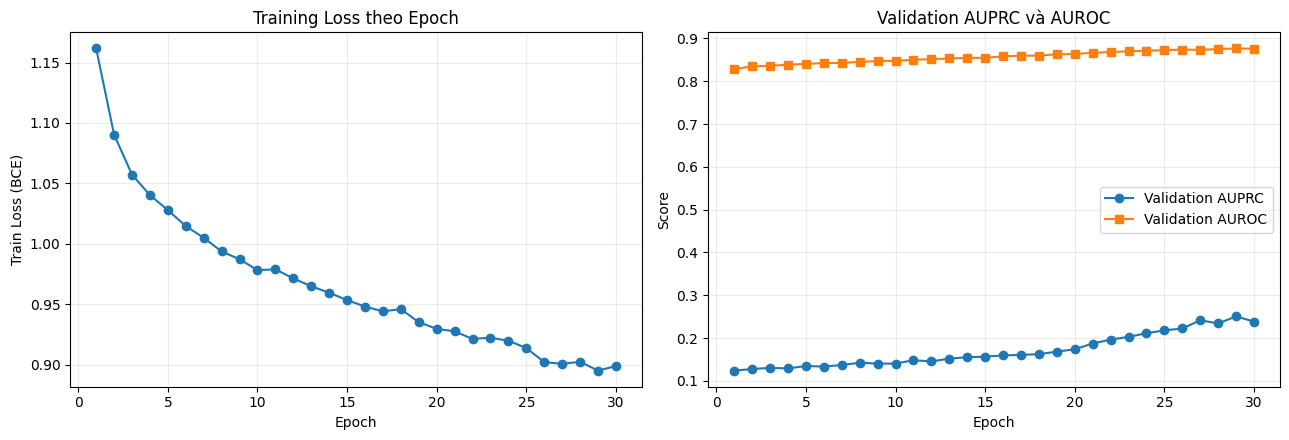

Đã lưu: /content/rba_outputs/training_curves.png


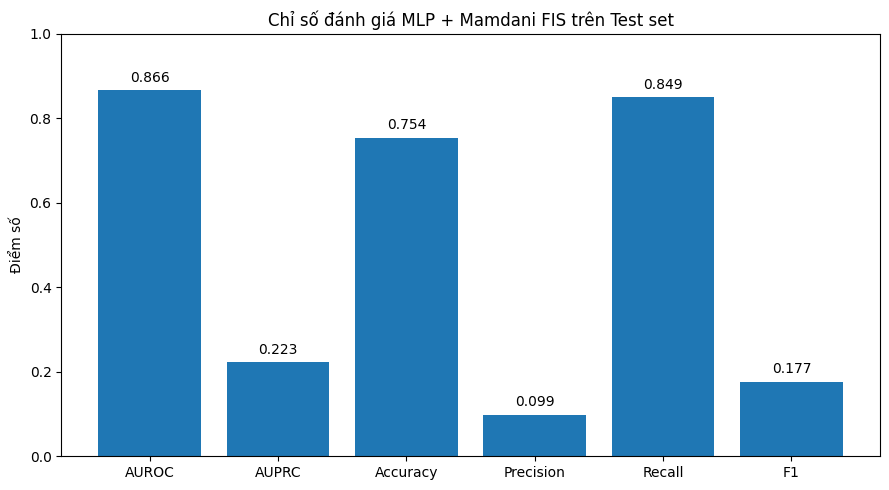

Đã lưu: /content/rba_outputs/metrics_bar_chart.png


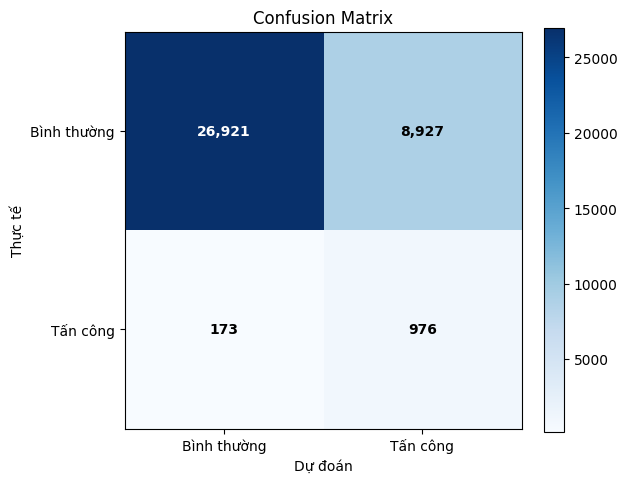

Đã lưu: /content/rba_outputs/confusion_matrix.png


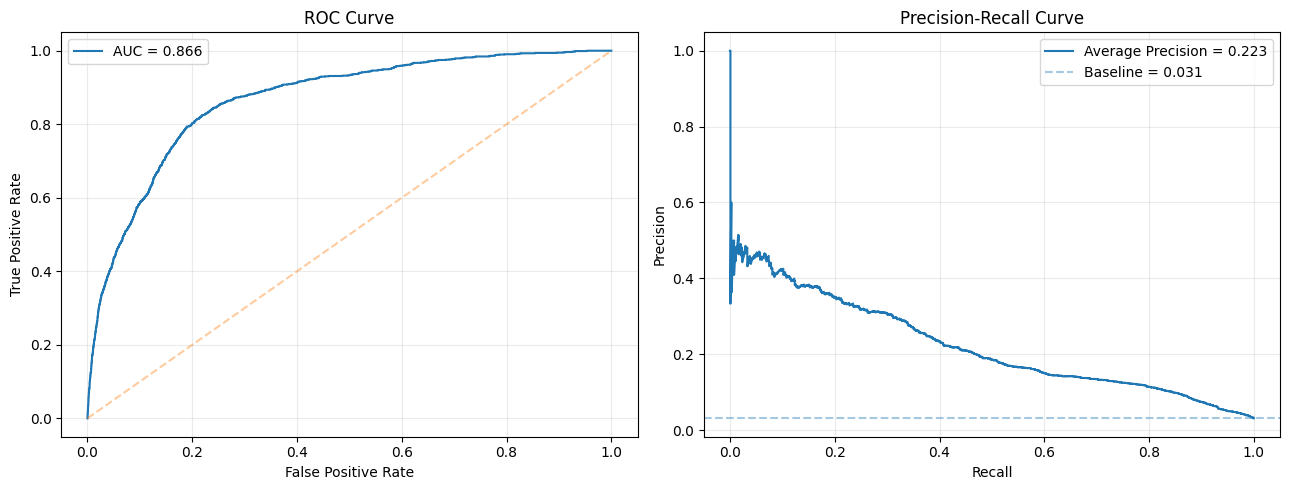

Đã lưu: /content/rba_outputs/roc_pr_curves.png


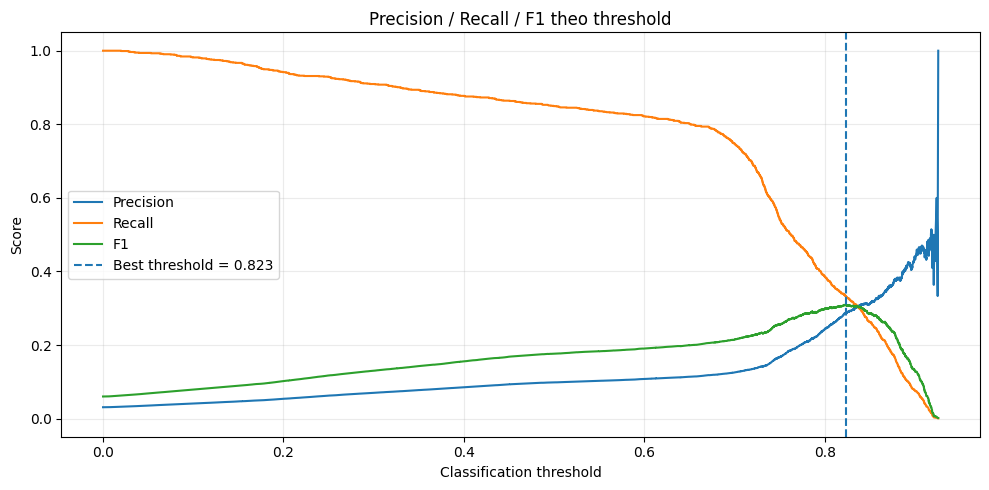

Đã lưu: /content/rba_outputs/threshold_curve.png
Best F1 threshold = 0.8232 | Precision = 0.2883 | Recall = 0.3342 | F1 = 0.3096


In [ ]:
plot_training_curves(history)
plot_metrics_bar(results)
plot_confusion_matrix_chart(results)
plot_roc_pr_curves(results)
best_threshold = plot_threshold_curve(results)

## Bước 19 — Lưu model, pipeline và metrics

In [ ]:
checkpoint = {
    "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()},
    "input_dim": pipeline["input_dim"],
    "hidden_dims": tuple(HIDDEN_DIMS),
    "dropout": float(DROPOUT),
    "best_threshold": float(best_threshold),
}
torch.save(checkpoint, MODEL_PATH)

with open(PIPELINE_PATH, "wb") as file:
    pickle.dump(pipeline, file)

metrics_to_save = {metric: float(results[metric]) for metric in METRICS}
metrics_to_save["threshold_0_5"] = 0.5
metrics_to_save["best_f1_threshold"] = float(best_threshold)

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics_to_save, file, ensure_ascii=False, indent=2)

print("Đã lưu model  :", MODEL_PATH)
print("Đã lưu pipeline:", PIPELINE_PATH)
print("Đã lưu metrics :", METRICS_PATH)
print("\nCác file output:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"- {path.name}: {path.stat().st_size / 1024:.1f} KB")

Đã lưu model  : /content/rba_outputs/mlp_mamdani_model.pt
Đã lưu pipeline: /content/rba_outputs/preprocessing_pipeline.pkl
Đã lưu metrics : /content/rba_outputs/metrics.json

Các file output:
- confusion_matrix.png: 36.9 KB
- metrics.json: 0.3 KB
- metrics_bar_chart.png: 40.6 KB
- mlp_mamdani_model.pt: 71.6 KB
- preprocessing_pipeline.pkl: 2.7 KB
- roc_pr_curves.png: 88.6 KB
- threshold_curve.png: 75.2 KB
- training_curves.png: 78.1 KB


## Bước 20 — Load model đã lưu và dự đoán dữ liệu mới

In [ ]:
def load_pipeline_and_model():
    with open(PIPELINE_PATH, "rb") as file:
        loaded_pipeline = pickle.load(file)

    checkpoint = torch.load(MODEL_PATH, map_location="cpu")
    loaded_model = MLPClassifier(
        input_dim=checkpoint["input_dim"],
        hidden_dims=tuple(checkpoint["hidden_dims"]),
        dropout=checkpoint["dropout"],
    )
    loaded_model.load_state_dict(checkpoint["state_dict"])
    loaded_model.eval()

    return loaded_model, loaded_pipeline, checkpoint


def predict_risk(
    engineered_rows: pd.DataFrame,
    loaded_model,
    loaded_pipeline,
    threshold=0.5,
):
    fis = MamdaniFuzzyRiskSystem()
    fis.thresholds_ = loaded_pipeline["fis_thresholds"]
    fuzzy_data = fis.transform(engineered_rows)

    categorical_data = pd.DataFrame(
        loaded_pipeline["ohe"].transform(
            engineered_rows[FEATURE_COLUMNS_CATEGORICAL]
        ),
        columns=loaded_pipeline["cat_cols"],
        index=engineered_rows.index,
    )

    numeric_data = pd.DataFrame(
        loaded_pipeline["scaler"].transform(
            engineered_rows[FEATURE_COLUMNS_NUMERIC]
        ),
        columns=FEATURE_COLUMNS_NUMERIC,
        index=engineered_rows.index,
    )

    X_new = pd.concat(
        [numeric_data, categorical_data, fuzzy_data],
        axis=1,
    )[loaded_pipeline["input_columns"]]

    loaded_model.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(loaded_model(to_tensor(X_new))).numpy()

    output = engineered_rows.copy()
    output["mamdani_risk_score"] = fuzzy_data["mamdani_risk_score"]
    output["attack_probability"] = probabilities
    output["predicted_label"] = (probabilities >= threshold).astype(int)
    return output

## Bước 21 — Demo inference với kịch bản rủi ro cao và thấp

In [ ]:
loaded_model, loaded_pipeline, loaded_checkpoint = load_pipeline_and_model()

scenario_high_risk = df.iloc[[0]].copy()
for col in [
    "is_new_country", "is_new_city", "is_new_asn",
    "is_new_device", "is_new_browser", "is_new_os", "is_odd_hour",
]:
    scenario_high_risk[col] = 1
scenario_high_risk["num_changes"] = 6
scenario_high_risk["time_since_last_login_h"] = 5000
scenario_high_risk["user_success_rate_so_far"] = 0.2
scenario_high_risk["country_rarity"] = 0.99
scenario_high_risk["asn_rarity"] = 0.99

scenario_low_risk = df.iloc[[0]].copy()
for col in [
    "is_new_country", "is_new_city", "is_new_asn",
    "is_new_device", "is_new_browser", "is_new_os", "is_odd_hour",
]:
    scenario_low_risk[col] = 0
scenario_low_risk["num_changes"] = 0
scenario_low_risk["time_since_last_login_h"] = 24
scenario_low_risk["user_success_rate_so_far"] = 1.0
scenario_low_risk["country_rarity"] = 0.05
scenario_low_risk["asn_rarity"] = 0.05

scenarios = pd.concat([scenario_high_risk, scenario_low_risk])
scenarios.index = ["RỦI RO CAO", "RỦI RO THẤP"]

inference_threshold = loaded_checkpoint.get("best_threshold", 0.5)
prediction = predict_risk(
    scenarios,
    loaded_model,
    loaded_pipeline,
    threshold=inference_threshold,
)

display(
    prediction[[
        "mamdani_risk_score",
        "attack_probability",
        "predicted_label",
    ]]
)
print("Threshold inference:", inference_threshold)

,mamdani_risk_score,attack_probability,predicted_label
RỦI RO CAO,0.840000,0.783795,0
RỦI RO THẤP,0.318984,0.401954,0


Threshold inference: 0.8231515884399414


## Bước 22 — Ablation Study: MLP có Fuzzy vs. MLP không Fuzzy

**Mục tiêu**: chứng minh tầng Mamdani FIS thực sự đóng góp vào hiệu năng, bằng
cách huấn luyện lại **cùng một kiến trúc MLP, cùng tập train/val/test, cùng
seed**, nhưng **bỏ toàn bộ 16 đặc trưng fuzzy** (`fz_*` và `mamdani_risk_score`)
khỏi input. Nếu MLP+Fuzzy tốt hơn rõ rệt, đó là bằng chứng tầng fuzzy mang lại
tín hiệu mà bản thân mạng nơ-ron không tự trích xuất được tốt bằng chỉ từ dữ
liệu thô.

In [ ]:
# Loại bỏ các cột đặc trưng fuzzy khỏi input
X_train_nf = X_train.drop(columns=FUZZY_FEATURE_COLUMNS)
X_val_nf = X_val.drop(columns=FUZZY_FEATURE_COLUMNS)
X_test_nf = X_test.drop(columns=FUZZY_FEATURE_COLUMNS)

print(f"Input dim CÓ fuzzy   : {X_train.shape[1]}")
print(f"Input dim KHÔNG fuzzy: {X_train_nf.shape[1]}  (giảm {len(FUZZY_FEATURE_COLUMNS)} chiều)")


Input dim CÓ fuzzy   : 39
Input dim KHÔNG fuzzy: 23  (giảm 16 chiều)


In [ ]:
t0 = time.time()

model_nofuzzy, device_nofuzzy, history_nofuzzy = train_mlp(
    X_train_nf,
    y_train,
    X_val_nf,
    y_val,
    input_dim=X_train_nf.shape[1],
)

print(f"Train (không fuzzy) xong trong {(time.time() - t0) / 60:.2f} phút")


Epoch 01/30 | loss=1.1790 | val_AUPRC=0.1197 | val_AUROC=0.8186 | lr=1.00e-03
Epoch 02/30 | loss=1.1009 | val_AUPRC=0.1230 | val_AUROC=0.8273 | lr=1.00e-03
Epoch 03/30 | loss=1.0698 | val_AUPRC=0.1262 | val_AUROC=0.8317 | lr=1.00e-03
Epoch 04/30 | loss=1.0474 | val_AUPRC=0.1301 | val_AUROC=0.8335 | lr=1.00e-03
Epoch 05/30 | loss=1.0332 | val_AUPRC=0.1322 | val_AUROC=0.8368 | lr=1.00e-03
Epoch 06/30 | loss=1.0230 | val_AUPRC=0.1326 | val_AUROC=0.8375 | lr=1.00e-03
Epoch 07/30 | loss=1.0127 | val_AUPRC=0.1330 | val_AUROC=0.8400 | lr=1.00e-03
Epoch 08/30 | loss=1.0063 | val_AUPRC=0.1345 | val_AUROC=0.8410 | lr=1.00e-03
Epoch 09/30 | loss=1.0016 | val_AUPRC=0.1354 | val_AUROC=0.8420 | lr=1.00e-03
Epoch 10/30 | loss=1.0023 | val_AUPRC=0.1406 | val_AUROC=0.8425 | lr=1.00e-03
Epoch 11/30 | loss=1.0006 | val_AUPRC=0.1393 | val_AUROC=0.8442 | lr=1.00e-03
Epoch 12/30 | loss=0.9923 | val_AUPRC=0.1416 | val_AUROC=0.8444 | lr=1.00e-03
Epoch 13/30 | loss=0.9859 | val_AUPRC=0.1451 | val_AUROC=0.8456 

In [ ]:
# Đánh giá với threshold=0.5, cùng cách đo với mô hình chính ở Bước 16
results_nofuzzy = evaluate(model_nofuzzy, X_test_nf, y_test, device_nofuzzy, threshold=0.5)

metrics_nofuzzy_df = pd.DataFrame(
    {"Metric": METRICS, "Score": [results_nofuzzy[m] for m in METRICS]}
)
display(metrics_nofuzzy_df.style.format({"Score": "{:.4f}"}))


,Metric,Score
0,AUROC,0.8454
1,AUPRC,0.1480
2,Accuracy,0.7614
3,Precision,0.0988
4,Recall,0.8225
5,F1,0.1763


### So sánh kết quả

Bảng và biểu đồ dưới so sánh trực tiếp 2 mô hình trên **cùng tập test** (threshold=0.5 cho cả hai để công bằng).

In [ ]:
comparison = pd.DataFrame({
    "MLP (không Fuzzy)": {m: results_nofuzzy[m] for m in METRICS},
    "MLP + Mamdani FIS": {m: results[m] for m in METRICS},
})
comparison["Chênh lệch (Fuzzy − No-Fuzzy)"] = (
    comparison["MLP + Mamdani FIS"] - comparison["MLP (không Fuzzy)"]
)
display(comparison.round(4))


,MLP (không Fuzzy),MLP + Mamdani FIS,Chênh lệch (Fuzzy − No-Fuzzy)
AUROC,0.8454,0.8664,0.0210
AUPRC,0.1480,0.2226,0.0747
Accuracy,0.7614,0.7540,-0.0074
Precision,0.0988,0.0986,-0.0002
Recall,0.8225,0.8494,0.0270
F1,0.1763,0.1766,0.0003


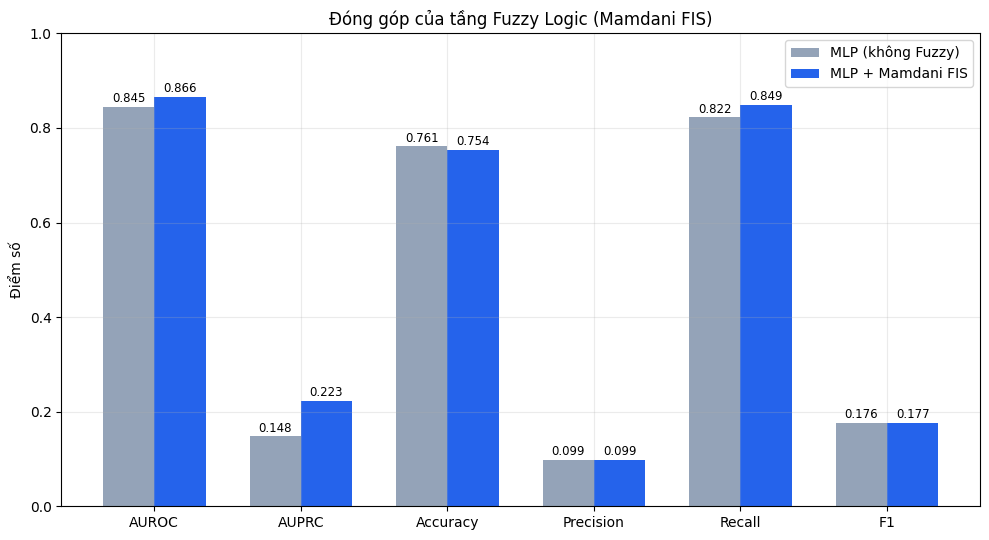

Đã lưu: /content/rba_outputs/ablation_comparison.png


In [28]:
x = np.arange(len(METRICS))
width = 0.35

vals_nf = [results_nofuzzy[m] for m in METRICS]
vals_f = [results[m] for m in METRICS]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars1 = ax.bar(x - width / 2, vals_nf, width, label="MLP (không Fuzzy)", color="#94a3b8")
bars2 = ax.bar(x + width / 2, vals_f, width, label="MLP + Mamdani FIS", color="#2563eb")

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center", fontsize=8.5)

ax.set_xticks(x)
ax.set_xticklabels(METRICS)
ax.set_ylim(0, 1)
ax.set_ylabel("Điểm số")
ax.set_title("Đóng góp của tầng Fuzzy Logic (Mamdani FIS)")
ax.legend()
ax.grid(alpha=0.25)

save_and_show(fig, "ablation_comparison.png")


**Kết quả ablation** (khớp với bảng ở cell trên; chạy trên mẫu ~246.600 dòng, 30 epoch, cùng seed):

| Metric | MLP (không Fuzzy) | MLP + Mamdani FIS | Chênh lệch |
|---|---|---|---|
| AUROC | 0.8454 | 0.8664 | **+0.0210** |
| AUPRC | 0.1480 | 0.2226 | **+0.0747** |
| Accuracy | 0.7614 | 0.7540 | −0.0074 |
| Precision | 0.0988 | 0.0986 | −0.0002 |
| Recall | 0.8225 | 0.8494 | **+0.0270** |
| F1 | 0.1763 | 0.1766 | +0.0003 |

Tầng Mamdani FIS cải thiện **rõ nhất ở AUPRC (+0.0747) và Recall (+0.0270)** — hai chỉ số quan trọng nhất với dữ liệu lệch lớp ~3%; Accuracy/Precision gần như không đổi. Điều này hợp lý vì các đặc trưng fuzzy là **hàm phi tuyến tường minh của cùng những biến thô** mà MLP đã có sẵn; MLP có thể tự học một phần, nhưng việc mã hoá sẵn tri thức chuyên gia (8 luật IF–THEN) giúp mô hình hội tụ tới tín hiệu rủi ro rõ ràng hơn.

## Bước 23 — Nén và tải toàn bộ kết quả

File ZIP gồm model, pipeline, metrics và các biểu đồ đã tạo.

In [ ]:
ZIP_PATH = Path("/content/rba_outputs.zip")
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

shutil.make_archive(
    base_name=str(ZIP_PATH.with_suffix("")),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Đã tạo:", ZIP_PATH)

try:
    from google.colab import files
    files.download(str(ZIP_PATH))
except ModuleNotFoundError:
    print("Notebook không chạy trong Colab; file nằm tại:", ZIP_PATH)